In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import torch

from src.config import SEED
from src.transfer import build_feature_extractor, train_transfer

torch.manual_seed(SEED)

# Transfer Learning con ResNet50
## Fase 4 - Feature Extraction

En lugar de entrenar una red desde cero como la CNN, aprovechamos **ResNet50 preentrenada en ImageNet**: una red que ya aprendió a reconocer bordes, texturas y estructuras visuales complejas en 1.2 millones de imágenes.

Usamos ImageNet específicamente porque normalizamos nuestras imágenes con sus stats (mean y std), lo que garantiza que la red recibe los datos en el rango que espera.

**Estrategia: Feature Extraction**  
El backbone de ResNet50 queda completamente congelado. Solo se entrena el clasificador final (fc), que reemplaza la cabeza original (2048 → 1000 clases ImageNet) por una binaria (2048 $\rightarrow$ 1 logit).

| Qué se entrena | LR | Parámetros entrenables |
|---|---|---|
| Solo clasificador (fc) | 1e-3 | aprox 2049 |

In [2]:
model = build_feature_extractor()

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales:      {total:,}")
print(f"Parámetros entrenables:  {trainable:,}  ({100*trainable/total:.1f}%)")

Parámetros totales:      23,510,081
Parámetros entrenables:  2,049  (0.0%)


Dispositivo: cuda


Epoch   1/50  train_loss=0.4192  val_loss=0.3563  val_acc=0.8465


Epoch   2/50  train_loss=0.3378  val_loss=0.3179  val_acc=0.8718


Epoch   3/50  train_loss=0.3169  val_loss=0.3107  val_acc=0.8698


Epoch   4/50  train_loss=0.3053  val_loss=0.2964  val_acc=0.8788


...

Epoch  20/50  train_loss=0.2815  val_loss=0.2810  val_acc=0.8855


Epoch  21/50  train_loss=0.2806  val_loss=0.2787  val_acc=0.8848


Epoch  22/50  train_loss=0.2796  val_loss=0.2792  val_acc=0.8860


Epoch  23/50  train_loss=0.2803  val_loss=0.2832  val_acc=0.8830


Early stopping en epoch 23.

Mejor val_loss: 0.2760


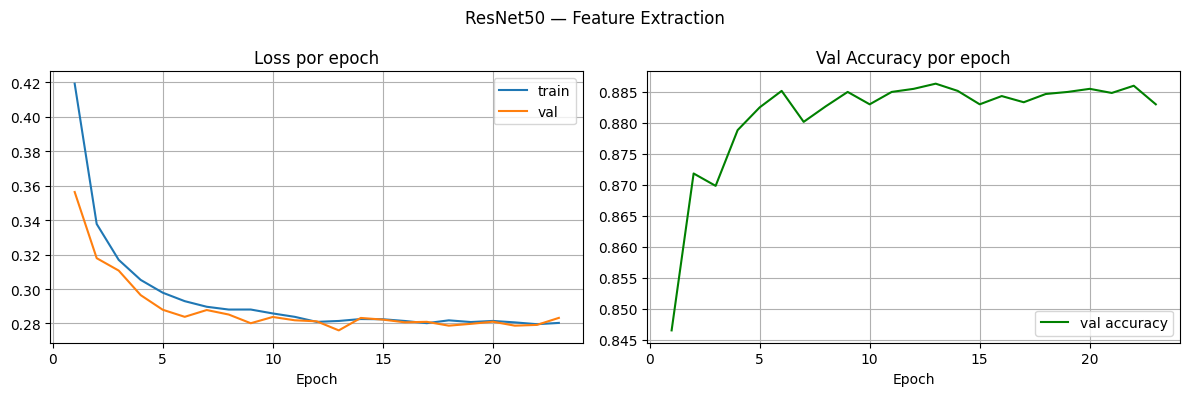

In [3]:
historial = train_transfer(model)